# *Project 1*: GooglePay Expense Sharing System

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Dummy Expense Data
data = {
    'Transaction_ID': [101, 102, 103, 104, 105],
    'Payer': ['Rahul', 'Amit', 'Priya', 'Rahul', 'Neha'],
    'Amount': [1200, 800, 1500, 600, 400],
    'Category': ['Food', 'Fuel', 'Hotel', 'Snacks', 'Cab'],
    'Split_Among': ['Rahul, Amit, Priya, Neha', 'Rahul, Amit', 'Rahul, Amit, Priya, Neha', 'Rahul, Priya', 'Neha, Amit'],
    'Status': ['Completed', 'Completed', 'Completed', 'Pending', 'Refunded']
}

df = pd.DataFrame(data)
print("--- Raw Expense Dataset ---")
print(df)


--- Raw Expense Dataset ---
   Transaction_ID  Payer  Amount Category               Split_Among     Status
0             101  Rahul    1200     Food  Rahul, Amit, Priya, Neha  Completed
1             102   Amit     800     Fuel               Rahul, Amit  Completed
2             103  Priya    1500    Hotel  Rahul, Amit, Priya, Neha  Completed
3             104  Rahul     600   Snacks              Rahul, Priya    Pending
4             105   Neha     400      Cab                Neha, Amit   Refunded


In [2]:
# Filter out 'Refunded' transactions for accurate calculation
valid_df = df[df['Status'] != 'Refunded'].copy()

# List of all unique users
users = ['Rahul', 'Amit', 'Priya', 'Neha']

# Calculate Total Paid by each person
total_paid = valid_df.groupby('Payer')['Amount'].sum().reindex(users, fill_value=0)

# Calculate Total Share (की किसको कितना पे करना बनता था)
fair_shares = {user: 0.0 for user in users}

for idx, row in valid_df.iterrows():
    split_users = [u.strip() for u in row['Split_Among'].split(',')]
    split_amount = row['Amount'] / len(split_users)
    for user in split_users:
        if user in fair_shares:
            fair_shares[user] += split_amount

# Create Net Balance DataFrame
balance_df = pd.DataFrame({
    'Paid': total_paid,
    'Fair_Share': pd.Series(fair_shares)
})

# Net Balance = Paid - Fair Share
# Positive (+) means person gets money back
# Negative (-) means person owes money
balance_df['Net_Balance'] = balance_df['Paid'] - balance_df['Fair_Share']

print("\n--- Final Net Balance Summary ---")
print(balance_df)



--- Final Net Balance Summary ---
       Paid  Fair_Share  Net_Balance
Rahul  1800      1375.0        425.0
Amit    800      1075.0       -275.0
Priya  1500       975.0        525.0
Neha      0       675.0       -675.0


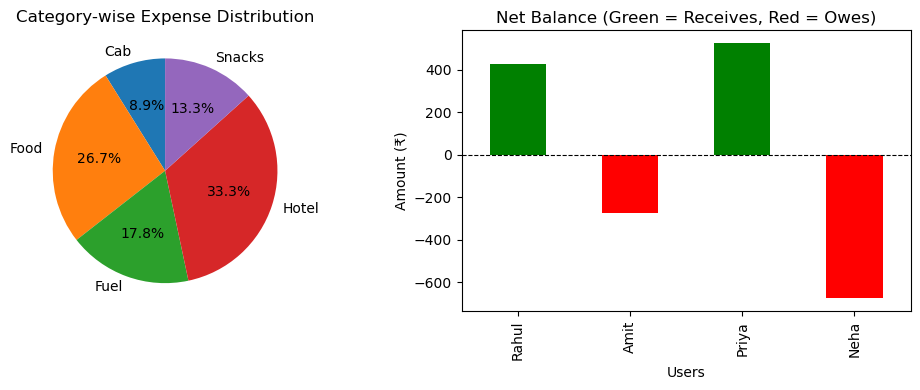

In [3]:
plt.figure(figsize=(10, 4))

# 1. Category-wise Spending
plt.subplot(1, 2, 1)
df.groupby('Category')['Amount'].sum().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Category-wise Expense Distribution')
plt.ylabel('')

# 2. Net Balance Per Person
plt.subplot(1, 2, 2)
colors = ['green' if x >= 0 else 'red' for x in balance_df['Net_Balance']]
balance_df['Net_Balance'].plot(kind='bar', color=colors)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Net Balance (Green = Receives, Red = Owes)')
plt.xlabel('Users')
plt.ylabel('Amount (₹)')

plt.tight_layout()
plt.show()
